In [18]:
import torch
from scipy.sparse import coo_matrix
from torch_geometric.data import Data
import networkx as nx
from torch_geometric.utils import to_networkx

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [19]:
first_row = pd.read_csv("fer13-split/train.csv", nrows=1)
pixel_str = first_row.loc[0, "pixels"]   # "70 80 82 ..."

img_array = np.fromstring(pixel_str, sep=" ", dtype=np.uint8).reshape(48, 48)

# 1. Image &rarr; Graph

In [ ]:
# Bước 1: Tạo node features (intensity của mỗi pixel)

H, W = 48, 48   # N = 2304 nodes
img = img_array.reshape(-1)    # node features: shape (2304,)

# Bước 2: Xây edge list (4 chiều + 4 đường chéo)
# Thay vì lưu ma trận kề -> lưu edge list
rows, cols = [], []
for r in range(H):
  for c in range(W):
    i = r * W + c           # node id của pixel (r,c)
    for dr, dc in [(-1,0),(1,0),(0,-1),(0,1),(-1,-1),(-1,1),(1,-1),(1,1)]:
      nr, nc = r+dr, c+dc
      if 0 <= nr < H and 0 <= nc < W:
        j = nr * W + nc     # node id của láng giềng
        rows.append(i); cols.append(j)

# Bước 3: Sparse adjacency matrix (không lưu dense!)
data = np.ones(len(rows))
A = coo_matrix((data, (rows, cols)), shape=(H*W, H*W))

# PyTorch Geometric:
edge_index = torch.tensor([rows, cols], dtype=torch.long)
x = torch.tensor(img, dtype=torch.float).unsqueeze(1)
graph = Data(x=x, edge_index=edge_index)

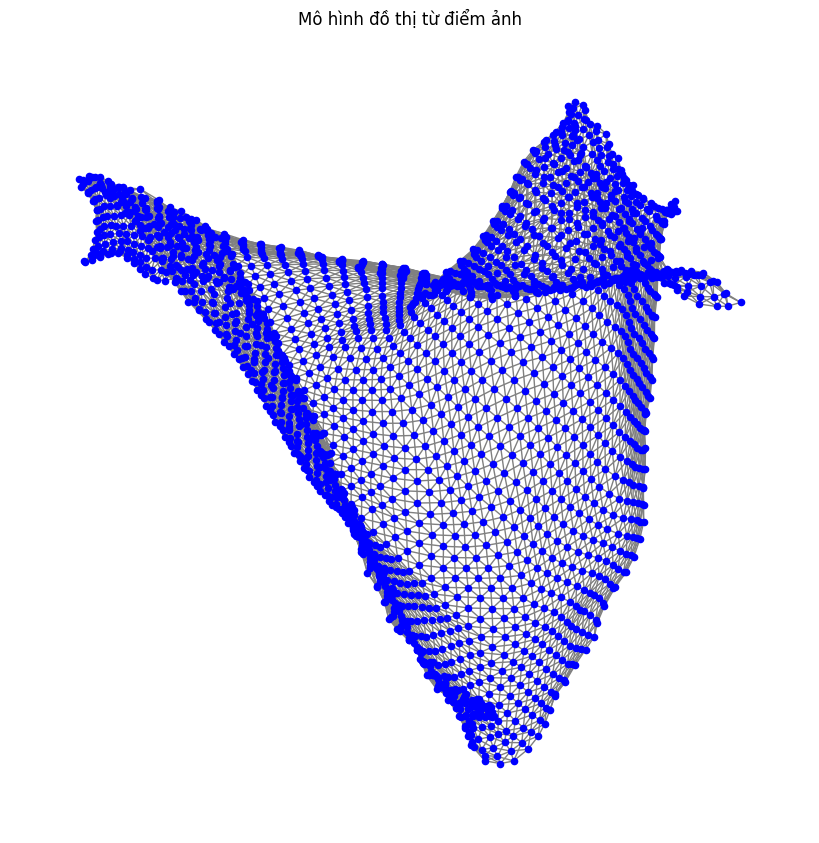

In [ ]:
G_visual = to_networkx(graph, to_undirected=True)

plt.figure(figsize=(8, 8))
nx.draw(G_visual, 
        node_size=20, 
        node_color='blue', 
        edge_color='gray', 
        with_labels=False)
plt.title("Mô hình đồ thị từ điểm ảnh")
plt.show()

In [ ]:
# Lấy danh sách hàng (node gốc) và cột (node đích)
rows = graph.edge_index[0]
cols = graph.edge_index[1]

print("--- DANH SÁCH 10 KẾT NỐI ĐẦU TIÊN ---")
for i in range(10):
    # Dùng .item() để chuyển từ định dạng Tensor của PyTorch sang số bình thường
    node_a = rows[i].item()
    node_b = cols[i].item()
    print(f"Node {node_a}  --->  Node {node_b}")

--- DANH SÁCH 10 KẾT NỐI ĐẦU TIÊN ---
Node 0  --->  Node 48
Node 0  --->  Node 1
Node 0  --->  Node 49
Node 1  --->  Node 49
Node 1  --->  Node 0
Node 1  --->  Node 2
Node 1  --->  Node 48
Node 1  --->  Node 50
Node 2  --->  Node 50
Node 2  --->  Node 1
